<h1 style="text-align:center; font-weight:bold; color: #db09bf;">
Model Architecture
</h1>

<hr style="width:50%; border:1px solid #db09bf; margin:auto;">

<h3 style="color: rgb(233, 150, 235); font-weight:bold;">
Data checking
</h3>

In [ ]:
import os
import pandas as pd
from IPython.display import display

splits = ["train", "val", "test"]
SOURCE_PATH = "NN_Data_set"

data = {}

for split in splits:
    split_path = os.path.join(SOURCE_PATH, split)
    data[split] = {}

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)

        if os.path.isdir(cls_path):
            data[split][cls] = len(os.listdir(cls_path))

df = pd.DataFrame(data).fillna(0).astype(int)
display(df)

,train,val,test
Plastic,603,99,101
Paper,567,101,102
Metal,613,101,102
Cardboard,553,99,100
Glass,614,101,103
Battery,584,104,106
Clothes,547,97,99


<div style="text-align:center;">

<h3 style="color:#db09bf; font-weight:bold; margin-bottom:5px;">
Custom CNN Architecture (From Scratch)
</h3>

<hr style="width:50%; border:1px solid #db09bf; margin:auto;">

</div>

<div style="display:flex; gap:20px; align-items:flex-start; justify-content:center;">

<!-- LEFT: MODEL ARCHITECTURE -->
<div style="
    display:inline-block;
    padding:10px 12px;
    border:3px solid #a730a1;
    border-radius:8px;
    background:#eba2f1;
    font-family:Arial;
    color:black;
    font-size:11px;
    line-height:1.2;
    font-weight:bold;
    width:300px;
">

Input Image (224×224×3)<br>↓<br>
Rescaling (1./255)<br>↓<br>
Conv2D (32 filters, 3×3, ReLU, L2)<br>↓<br>
Conv2D (32 filters, 3×3, ReLU, L2)<br>↓<br>
BatchNormalization<br>↓<br>
MaxPooling2D<br>↓<br>
Conv2D (64 filters, 3×3, ReLU, L2)<br>↓<br>
BatchNormalization<br>↓<br>
MaxPooling2D<br>↓<br>
Conv2D (128 filters, 3×3, ReLU, L2)<br>↓<br>
BatchNormalization<br>↓<br>
Conv2D (128 filters, 3×3, ReLU, L2)<br>↓<br>
BatchNormalization<br>↓<br>
MaxPooling2D<br>↓<br>
Dropout (0.4)<br>↓<br>
GlobalAveragePooling2D<br>↓<br>
Dense (128, ReLU, L2)<br>↓<br>
BatchNormalization<br>↓<br>
Dropout (0.5)<br>↓<br>
Output (Dense 7, Softmax)

</div>

<!-- RIGHT: IMAGE -->
<div style="width:750px; text-align:center;">
    <img src="layers.png" style="width:700px; height:auto; border:3px solid #a730a1; border-radius:8px;">
</div>

</div>

In [155]:
import numpy as np
from pathlib import Path
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [156]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

In [ ]:
train_ds = image_dataset_from_directory(
    "NN_Data_set/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = image_dataset_from_directory(
    "NN_Data_set/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

test_ds = image_dataset_from_directory(
    "NN_Data_set/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 4081 files belonging to 7 classes.
Found 702 files belonging to 7 classes.
Found 713 files belonging to 7 classes.


In [158]:
class_names = train_ds.class_names
print(class_names)

['Battery', 'Cardboard', 'Clothes', 'Glass', 'Metal', 'Paper', 'Plastic']


In [159]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

In [160]:
def build_model_from_scratch():
    model = tf.keras.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Rescaling(1./255),

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Dropout(0.4),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(7, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [161]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3
    )
]

In [162]:
CNN_model = build_model_from_scratch()

CNN_history = CNN_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    callbacks=callbacks
)

Epoch 1/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 55s 209ms/step - accuracy: 0.4256 - loss: 1.8384 - val_accuracy: 0.1410 - val_loss: 2.2185 - learning_rate: 3.0000e-04
Epoch 2/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 123ms/step - accuracy: 0.5153 - loss: 1.5349 - val_accuracy: 0.1410 - val_loss: 2.7820 - learning_rate: 3.0000e-04
Epoch 3/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.5643 - loss: 1.3468 - val_accuracy: 0.2265 - val_loss: 2.8230 - learning_rate: 3.0000e-04
Epoch 4/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.5866 - loss: 1.2612 - val_accuracy: 0.4373 - val_loss: 1.9443 - learning_rate: 3.0000e-04
Epoch 5/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step - accuracy: 0.6153 - loss: 1.1832 - val_accuracy: 0.2350 - val_loss: 4.9861 - learning_rate: 3.0000e-04
Epoch 6/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 123ms/step - accuracy: 0.6494 - loss: 1.0902 - val_accuracy: 0.3618 - val_loss: 2.0728 - learning_rate: 3.0000e-04
Epoch 7/40
128/128 ━━━━━━━━━━━━━━━━━━━━ 16s 12

In [174]:
test_loss, test_accuracy = CNN_model.evaluate(test_ds)

print("\n")
print(f"Test Accuracy: {round(test_accuracy * 100)}%")
print(f"Test Loss: {test_loss}")


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - accuracy: 0.7910 - loss: 0.6507


Test Accuracy: 79%
Test Loss: 0.6507054567337036


In [164]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = CNN_model.predict(images)

    # convert probabilities → class index
    pred_classes = np.argmax(predictions, axis=1)

    y_pred.extend(pred_classes)
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 633ms/step
              precision    recall  f1-score   support

     Battery       0.88      0.77      0.82       106
   Cardbo

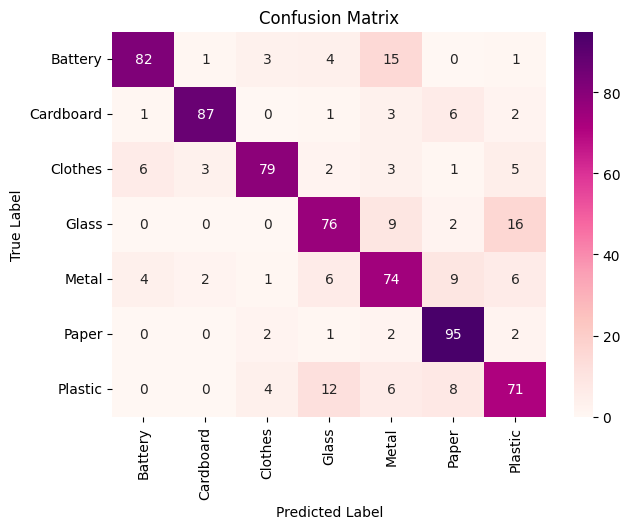

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [166]:
cnn_train_acc = CNN_history.history['accuracy']
cnn_val_acc = CNN_history.history['val_accuracy']

cnn_train_loss = CNN_history.history['loss']
cnn_val_loss = CNN_history.history['val_loss']

epochs = range(1, len(cnn_train_acc) + 1)

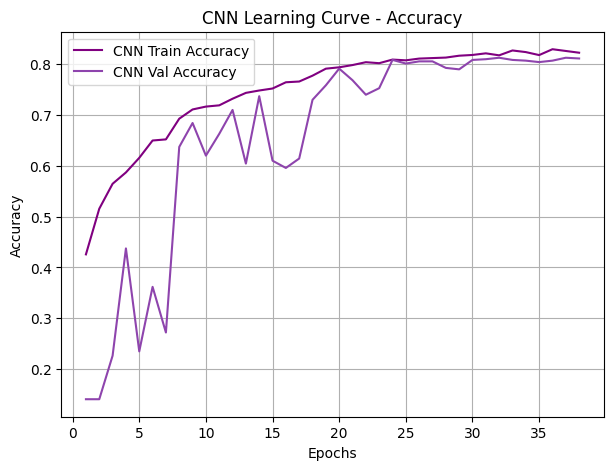

In [167]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(epochs, cnn_train_acc, label='CNN Train Accuracy', color='purple')
plt.plot(epochs, cnn_val_acc, label='CNN Val Accuracy', color='#8e44ad')

plt.title('CNN Learning Curve - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

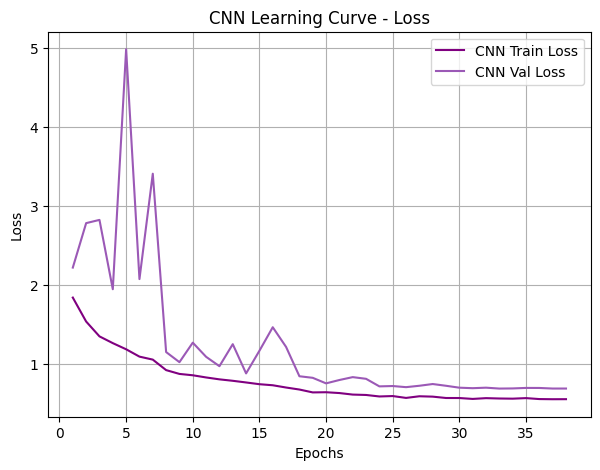

In [168]:
plt.figure(figsize=(7,5))

plt.plot(epochs, cnn_train_loss, label='CNN Train Loss', color='purple')
plt.plot(epochs, cnn_val_loss, label='CNN Val Loss', color='#9b59b6')

plt.title('CNN Learning Curve - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step


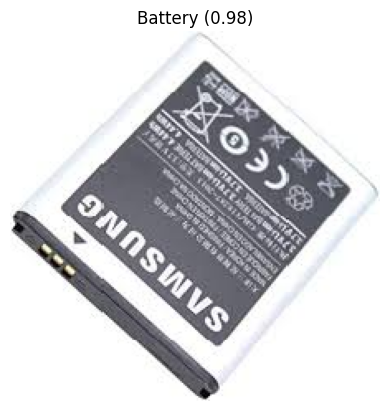

Prediction: Battery
Confidence: 0.97658175


In [ ]:
# Test new img

img_path = "test_img3.jpg"
from tensorflow.keras.preprocessing import image

# load image & same preprocessing
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# prediction
prediction = CNN_model.predict(img_array)
pred_class = np.argmax(prediction)
confidence = np.max(prediction)

# show result
plt.imshow(img)
plt.title(f"{class_names[pred_class]} ({confidence:.2f})")
plt.axis('off')
plt.show()

print("Prediction:", class_names[pred_class])
print("Confidence:", confidence)

In [ ]:
# Save the history for later analysis

# import pickle
# path = "/content/drive/MyDrive/garbage_cnn_history.pkl"
# with open(path, 'wb') as f:
#     pickle.dump(CNN_history.history, f)

In [ ]:
# Save the model for later use
# CNN_model.save("/content/drive/MyDrive/garbage_cnn_model.keras")

In [172]:
# call the model

# from tensorflow.keras.models import load_model
# CNN_model = load_model("garbage_model.h5")

In [173]:
# call thr history

# import pickle
# with open("garbage_cnn_history.pkl", "rb") as f:
#     CNN_history = pickle.load(f)